Import bibiotek

In [48]:
from xgboost import XGBClassifier
import pandas as pd
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

Model - only real data

In [46]:
# import plików
X_train=pd.read_csv('Dataset_secundo_testo/X_train.csv')
Y_train=pd.read_csv( 'Dataset_secundo_testo/train_set_RF_4c_1.csv')
X_test=pd.read_csv('Dataset_secundo_testo/X_test.csv')
Y_test=pd.read_csv( 'Dataset_secundo_testo/test_set_RF_4c_1.csv')

Y_test=Y_test['cluster_results_KMedoids']
Y_train=Y_train['cluster_results_KMedoids']

y_train_1d = np.array(Y_train).ravel()
y_test_1d = np.array(Y_test).ravel()

# parametry modelu
model = XGBClassifier(
    max_depth=4,
    learning_rate=0.1,
    objective='multi:softprob',
    num_class=4,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=1,
    n_estimators=10000,
    random_state=42,
    early_stopping_rounds=10,
)

model.fit(
    X_train,y_train_1d,
    sample_weight=compute_sample_weight('balanced', y_train_1d),
    eval_set=[(X_test, y_test_1d)],
    verbose=10,
)

[0]	validation_0-mlogloss:1.34664
[10]	validation_0-mlogloss:1.15199
[20]	validation_0-mlogloss:1.06017
[30]	validation_0-mlogloss:1.01765
[40]	validation_0-mlogloss:0.98686
[50]	validation_0-mlogloss:0.96812
[60]	validation_0-mlogloss:0.94927
[70]	validation_0-mlogloss:0.94031
[80]	validation_0-mlogloss:0.92923
[90]	validation_0-mlogloss:0.92582
[100]	validation_0-mlogloss:0.92026
[110]	validation_0-mlogloss:0.91616
[120]	validation_0-mlogloss:0.91409
[130]	validation_0-mlogloss:0.91216
[140]	validation_0-mlogloss:0.91074
[150]	validation_0-mlogloss:0.91122
[152]	validation_0-mlogloss:0.91214


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.85
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

Ewaluacja działania modelu Only real data - Matura

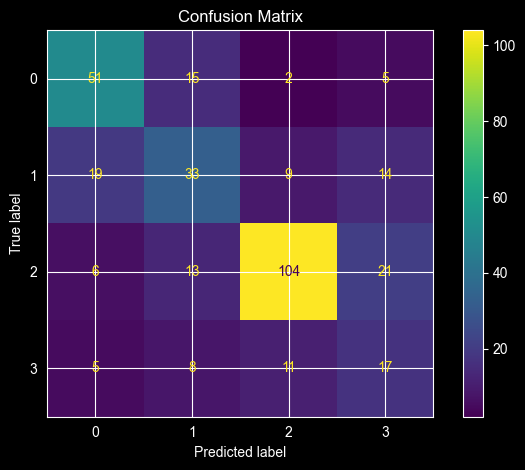

              precision    recall  f1-score   support

           0       0.63      0.70      0.66        73
           1       0.48      0.44      0.46        75
           2       0.83      0.72      0.77       144
           3       0.30      0.41      0.35        41

    accuracy                           0.62       333
   macro avg       0.56      0.57      0.56       333
weighted avg       0.64      0.62      0.62       333



In [47]:
preds = model.predict(X_test)

ConfusionMatrixDisplay.from_estimator(
    model, X_test, Y_test
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
print(classification_report(Y_test, preds))

Model - if everything else failed make some data from you ass

In [53]:
randome_generatiore=SMOTE(random_state=42)
X_train_fake_data, y_train_fake_data = randome_generatiore.fit_resample(X_train, y_train_1d)
model_f = XGBClassifier(
    max_depth=4,
    learning_rate=0.05,
    objective='multi:softprob',
    num_class=4,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=10000,
    random_state=42,
    early_stopping_rounds=10,
)

model_f.fit(
    X_train_fake_data,y_train_fake_data,
    sample_weight=compute_sample_weight('balanced', y_train_fake_data),
    eval_set=[(X_test, y_test_1d)],
    verbose=10,
)

[0]	validation_0-mlogloss:1.37004
[10]	validation_0-mlogloss:1.22917
[20]	validation_0-mlogloss:1.14106
[30]	validation_0-mlogloss:1.08854
[40]	validation_0-mlogloss:1.05133
[50]	validation_0-mlogloss:1.02358
[60]	validation_0-mlogloss:1.00062
[70]	validation_0-mlogloss:0.98722
[80]	validation_0-mlogloss:0.97213
[90]	validation_0-mlogloss:0.95504
[100]	validation_0-mlogloss:0.94329
[110]	validation_0-mlogloss:0.93482
[120]	validation_0-mlogloss:0.92536
[130]	validation_0-mlogloss:0.91833
[140]	validation_0-mlogloss:0.90956
[150]	validation_0-mlogloss:0.90452
[160]	validation_0-mlogloss:0.89587
[170]	validation_0-mlogloss:0.89170
[180]	validation_0-mlogloss:0.88811
[190]	validation_0-mlogloss:0.88442
[200]	validation_0-mlogloss:0.88134
[210]	validation_0-mlogloss:0.87786
[220]	validation_0-mlogloss:0.87747
[230]	validation_0-mlogloss:0.87562
[240]	validation_0-mlogloss:0.87236
[250]	validation_0-mlogloss:0.86946
[260]	validation_0-mlogloss:0.86805
[270]	validation_0-mlogloss:0.86521
[28

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from

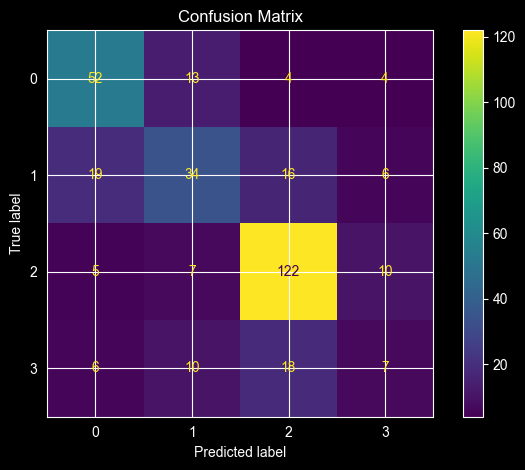

              precision    recall  f1-score   support

           0       0.63      0.71      0.67        73
           1       0.53      0.45      0.49        75
           2       0.76      0.85      0.80       144
           3       0.26      0.17      0.21        41

    accuracy                           0.65       333
   macro avg       0.55      0.55      0.54       333
weighted avg       0.62      0.65      0.63       333



In [54]:
preds_f = model_f.predict(X_test)

ConfusionMatrixDisplay.from_estimator(
    model_f, X_test, Y_test
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
print(classification_report(Y_test, preds_f))